# Principal Component Analysis (PCA) – Evaluation Version
## Dimensionality Reduction Lab (Iris Dataset)

Instructions:
- Complete all TODO sections.
- Add explanations where requested.
- Interpret your findings clearly.
- Submit the completed notebook.


## 1. Import Required Libraries
### TODO:
- Import NumPy
- Import Pandas
- Import Matplotlib
- Import Iris dataset
- Import StandardScaler
- Import PCA
- Import train_test_split
- Import LogisticRegression
- Import accuracy_score


In [1]:
# TODO: Write your import statements here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 2. Load the Iris Dataset
### TODO:
- Load the Iris dataset
- Convert features into a DataFrame
- Extract target variable
- Display dataset shape
- Display first 5 rows


In [2]:
# TODO: Load dataset here
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print('Dataset shape:', X.shape)
X.head()

Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Standardize the Features
### TODO:
- Initialize StandardScaler
- Fit and transform features
- Print mean and standard deviation

Why is feature scaling necessary before PCA?


In [3]:
# TODO: Standardize data here
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Mean (approx 0):', np.mean(X_scaled))
print('Std (approx 1):', np.std(X_scaled))

Mean (approx 0): -1.4684549872375404e-15
Std (approx 1): 1.0


## 4. Apply PCA
### TODO:
- Initialize PCA (without limiting components)
- Fit PCA on scaled data
- Extract explained_variance_
- Extract explained_variance_ratio_
- Print explained variance ratios

What does explained_variance_ratio_ represent?


In [5]:
# TODO: Apply PCA here
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio "What percentage of total variance is captured by each principal component."
explained_variance = pca.explained_variance_ratio_
print('explained variance ratios:', explained_variance)

explained variance ratios: [0.72962445 0.22850762 0.03668922 0.00517871]


## 5. Scree Plot
### TODO:
- Plot cumulative explained variance
- Label axes properly
- Interpret how many components are sufficient
- Determine number of components that explain at least 95% variance
Print that number


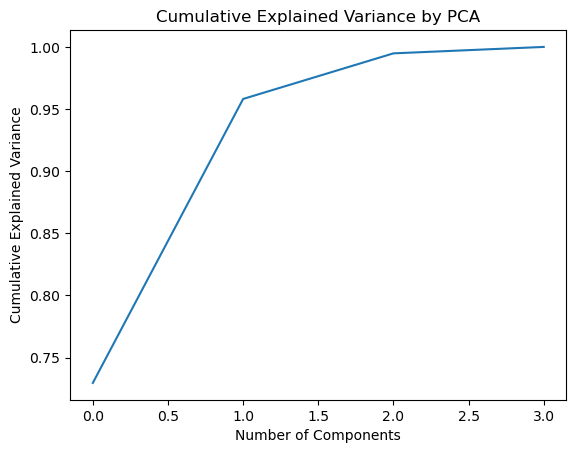

In [6]:
# TODO: Create scree plot here
plt.figure()
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA')
plt.show()

## 6. Reduce Dataset to 2 Principal Components
### TODO:
- Initialize PCA with n_components=2
- Transform dataset
- Print total explained variance

Is dimensionality reduction effective here?


In [9]:
# TODO: Reduce dimensions here
pca_2 = PCA(n_components=2)
X_reduced = pca_2.fit_transform(X_scaled)

# the first two principal components together explain 63.24% of the total variance.
print('Variance explained by 2 components:', sum(pca_2.explained_variance_ratio_))

Variance explained by 2 components: 0.9581320720000164


## 7. Visualize PCA Projection
### TODO:
- Create scatter plot of PC1 vs PC2
- Use class labels as color
- Label axes clearly

Describe class separability.


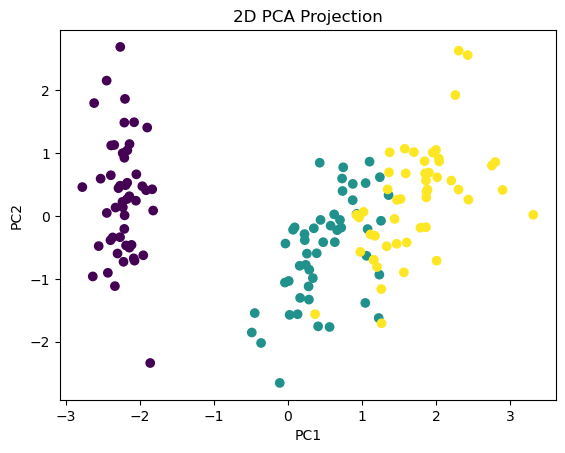

In [10]:
# TODO: Visualize PCA projection here
plt.figure()
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Projection')
plt.show()

## 8. Classification Before and After PCA
### TODO:
- Split original scaled dataset
- Train Logistic Regression
- Compute accuracy

- Split PCA-reduced dataset
- Train Logistic Regression
- Compute accuracy

Compare both results and explain differences.


In [15]:
# TODO: Train and evaluate model here
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model_original = LogisticRegression(max_iter=100) # Default is often 100.
model_original.fit(X_train, y_train)
y_pred_original = model_original.predict(X_test)
print('Accuracy (Original):', accuracy_score(y_test, y_pred_original))

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
model_pca = LogisticRegression(max_iter=100)
model_pca.fit(X_train_pca, y_train)
y_pred_pca = model_pca.predict(X_test_pca)
print('Accuracy (After PCA):', accuracy_score(y_test, y_pred_pca))

Accuracy (Original): 1.0
Accuracy (After PCA): 0.9


## 9. Reconstruction Error
### TODO:
- Reconstruct original data from 2 components
- Compute reconstruction error (MSE)

What does reconstruction error indicate?

In [16]:
# TODO: Compute reconstruction error here

# Reconstruct from 2 principal components
X_reconstructed = pca_2.inverse_transform(X_reduced)

# Compute Mean Squared Error (Reconstruction Error)
mse = np.mean((X_scaled - X_reconstructed) ** 2)
print("Reconstruction Error (MSE):", mse)

Reconstruction Error (MSE): 0.0418679279999836


## 10. Final Reflection
### TODO:
- What is the benefit of PCA in this dataset?

For the Iris dataset:

Reduces 4 features → 2 features

Makes visualization possible in 2D

Removes correlated structure

Reduces dimensionality while keeping most variance

It helps especially for:

Visualization

Noise reduction

Faster training in larger datasets

- Did PCA reduce performance?

Yes — slightly.

Original accuracy: 1.0
After PCA: 0.9
Why?
Because PCA removed some information (about 37% variance).
That information helped classification slightly.
However, the drop is small — meaning PCA preserved most useful signal.

- When is PCA most useful?

PCA is most useful when:

 You have many features (high dimensional data)
 Features are highly correlated
 You want faster training
 You want data visualization
 You want noise reduction
